# 01 — Returns & Volatility

Builds on the Day 4–10 yfinance loader (`market_data_analyzer.data_loader`), which writes
the 5-ticker Adj Close panel to `data/raw/adj_close.csv`.

**Definitions**

1. Simple return: $R_t = \dfrac{P_t}{P_{t-1}} - 1$
2. Log return: $r_t = \ln\!\left(\dfrac{P_t}{P_{t-1}}\right) = \ln(1 + R_t)$
3. Annualized vol: $\sigma_{ann} = \sigma_{daily}\sqrt{252}$ (assumes i.i.d. daily returns, 252 trading days)

If the CSV is missing, regenerate it from the repo root:
```bash
python -m market_data_analyzer.data_loader
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})

## Load the 5-ticker price panel

In [2]:
# Works whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = ROOT / "data" / "raw" / "adj_close.csv"

px = pd.read_csv(PANEL, index_col="Date", parse_dates=True).sort_index()
print(px.shape, px.index.min().date(), "->", px.index.max().date())
px.tail()

(2950, 5) 2015-01-02 -> 2026-09-25


,AAPL,MSFT,GOOGL,JPM,SPY
Date,,,,,
2026-09-21,338.980011,501.609985,354.970001,352.040009,773.500000
2026-09-22,339.750000,498.000000,351.160004,340.000000,773.380005
2026-09-23,337.019989,500.589996,337.829987,337.529999,767.809998
2026-09-24,335.920013,497.929993,342.359985,338.559998,767.179993
2026-09-25,341.070007,516.169983,343.920013,343.059998,771.349976


## 1. Daily simple returns

In [3]:
returns = px.pct_change().dropna()
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,2949.000000,0.001061,0.018088,-0.128647,-0.007308,0.001001,0.010014,0.153289
MSFT,2949.000000,0.001021,0.017378,-0.147390,-0.007073,0.000912,0.009659,0.155067
GOOGL,2949.000000,0.001040,0.018319,-0.116341,-0.007885,0.001216,0.010067,0.162584
JPM,2949.000000,0.000824,0.016938,-0.149649,-0.007009,0.000769,0.008925,0.180125
SPY,2949.000000,0.000576,0.011050,-0.109424,-0.003707,0.000615,0.005930,0.105019


## 2. Daily log returns

In [4]:
log_returns = np.log(px / px.shift(1)).dropna()

# Sanity check: r = ln(1 + R)
assert np.allclose(log_returns, np.log1p(returns))
log_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,2949.000000,0.000898,0.018076,-0.137708,-0.007335,0.001000,0.009964,0.142618
MSFT,2949.000000,0.000871,0.017340,-0.159454,-0.007098,0.000911,0.009612,0.144159
GOOGL,2949.000000,0.000873,0.018276,-0.123685,-0.007917,0.001215,0.010016,0.150645
JPM,2949.000000,0.000681,0.016917,-0.162106,-0.007034,0.000768,0.008885,0.165620
SPY,2949.000000,0.000514,0.011073,-0.115887,-0.003714,0.000615,0.005912,0.099863


## 3. Annualized volatility

In [5]:
ann_vol = pd.DataFrame({
    "simple": returns.std() * np.sqrt(252),
    "log": log_returns.std() * np.sqrt(252),
}).sort_values("simple", ascending=False)
ann_vol.style.format("{:.2%}")

,simple,log
GOOGL,29.08%,29.01%
AAPL,28.71%,28.69%
MSFT,27.59%,27.53%
JPM,26.89%,26.85%
SPY,17.54%,17.58%


## 4. Charts

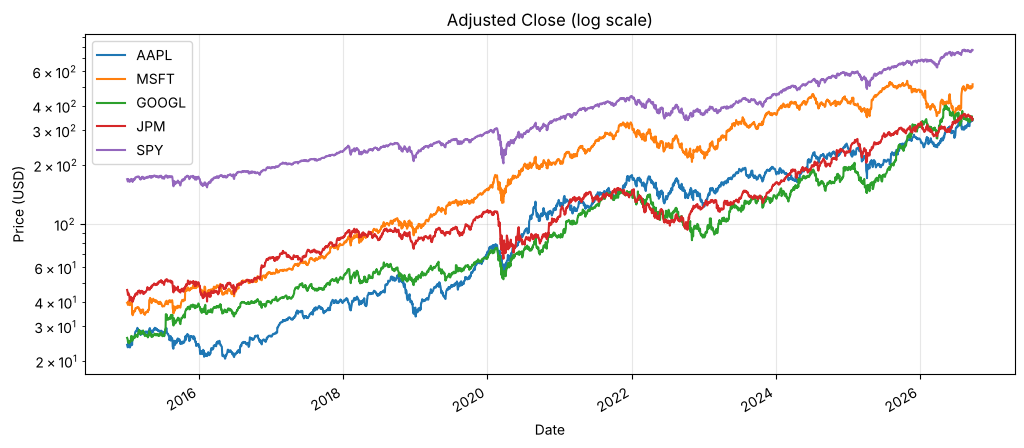

In [6]:
# 4a. Price series — log y-axis so % moves are comparable across price levels
ax = px.plot(logy=True, title="Adjusted Close (log scale)")
ax.set_ylabel("Price (USD)")
plt.show()

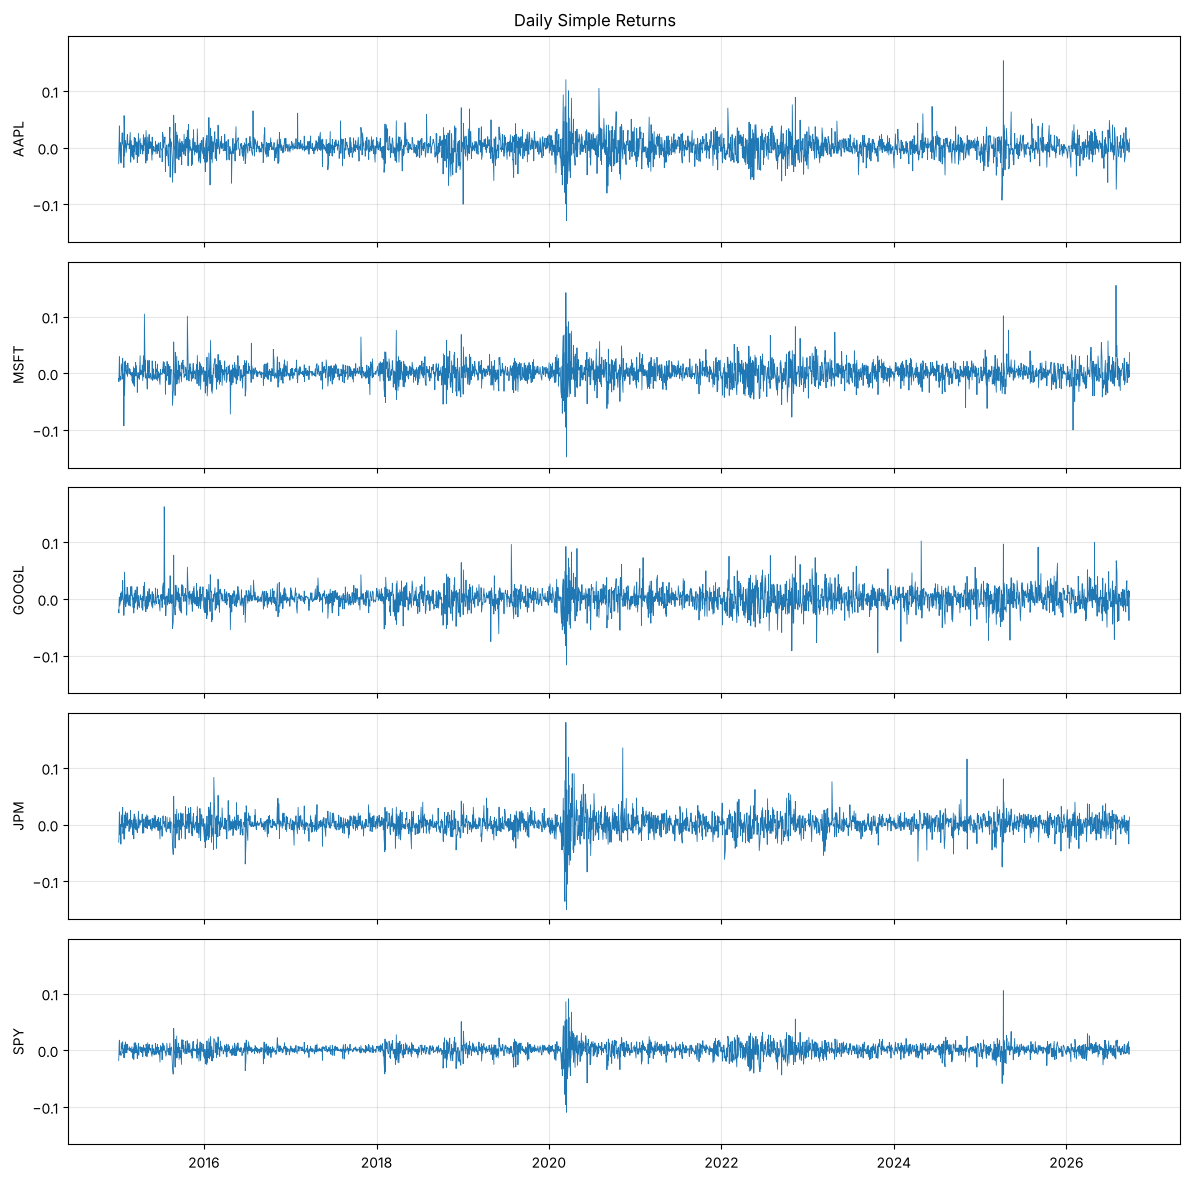

In [7]:
# 4b. Simple returns series
fig, axes = plt.subplots(len(px.columns), 1, figsize=(12, 12), sharex=True, sharey=True)
for ax, t in zip(axes, returns.columns):
    ax.plot(returns.index, returns[t], lw=0.6)
    ax.set_ylabel(t)
fig.suptitle("Daily Simple Returns")
fig.tight_layout()
plt.show()

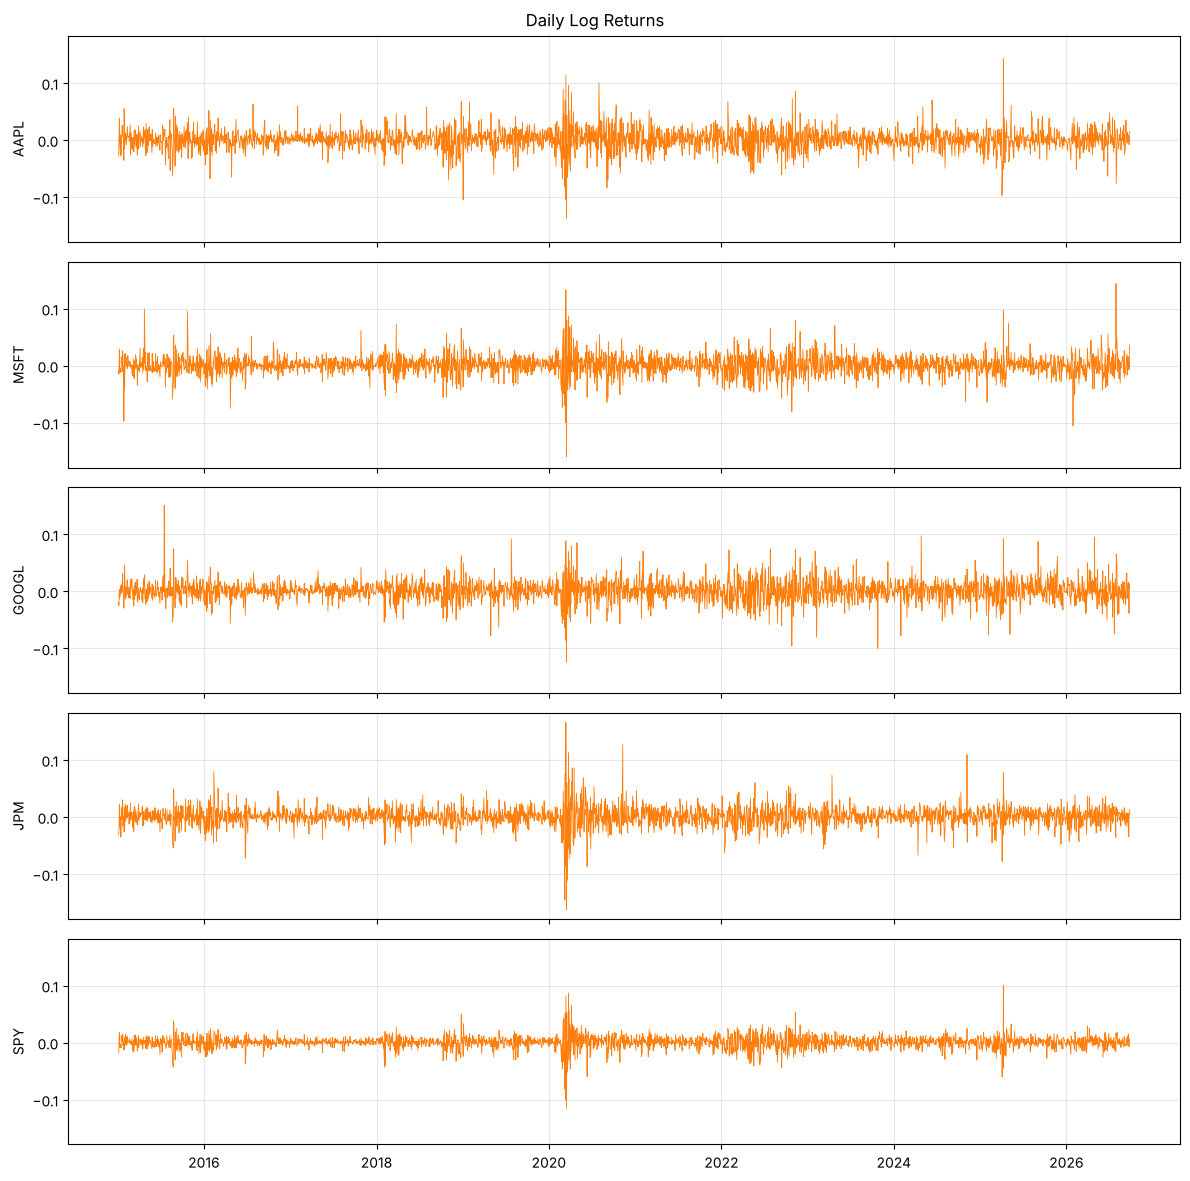

In [8]:
# 4c. Log returns series
fig, axes = plt.subplots(len(px.columns), 1, figsize=(12, 12), sharex=True, sharey=True)
for ax, t in zip(axes, log_returns.columns):
    ax.plot(log_returns.index, log_returns[t], lw=0.6, color="tab:orange")
    ax.set_ylabel(t)
fig.suptitle("Daily Log Returns")
fig.tight_layout()
plt.show()

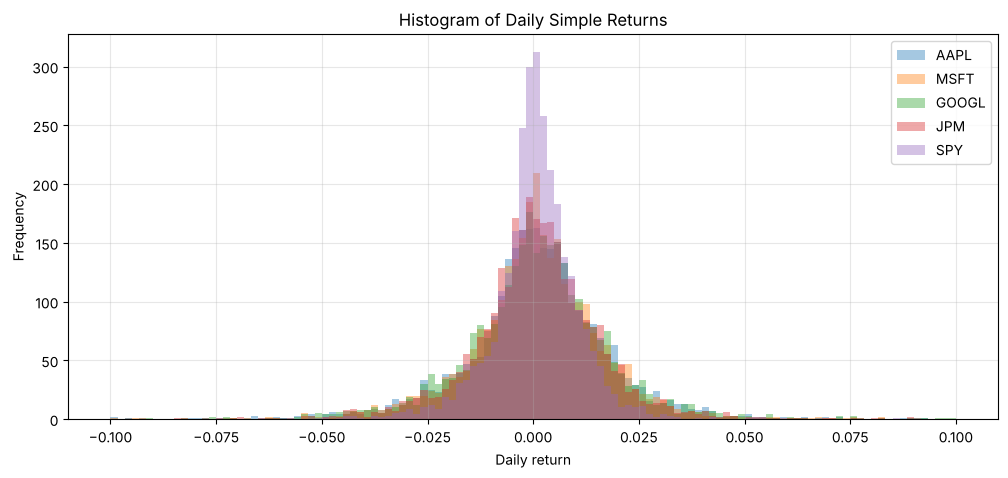

In [9]:
# 4d. Histogram of simple returns (overlaid)
bins = np.linspace(-0.10, 0.10, 121)
fig, ax = plt.subplots()
for t in returns.columns:
    ax.hist(returns[t], bins=bins, alpha=0.4, label=t)
ax.set_title("Histogram of Daily Simple Returns")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

## Takeaways

1. Log and simple returns are nearly identical at daily horizons ($\ln(1+R) \approx R$ for small $R$), so their annualized vols agree closely.
2. SPY has the lowest vol — diversification across 500 names; single stocks sit higher.
3. Fat tails and volatility clustering (e.g., March 2020) are visible — the i.i.d. normal assumption behind $\sqrt{252}$ scaling is only an approximation.